In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv("../commuting-regression/data_swindon_with_commute.csv")

features = [
    "log_voa_rv_2023", "rv_per_working_age", "sme_density", "qualification_index",
    "firm_size_diversity", "rv_per_employee", "sme_qual_interaction",
    "employment_quality", "modern_sector_leverage", "asset_growth_diversity",
    "msoa_out_commute_share", "msoa_same_msoa_work_share", "msoa_wfh_share",
    "msoa_in_commute_share", "msoa_local_worker_share",
]

X = StandardScaler().fit_transform(df[features])
df["cluster"] = KMeans(n_clusters=6, random_state=42, n_init=20).fit_predict(X)

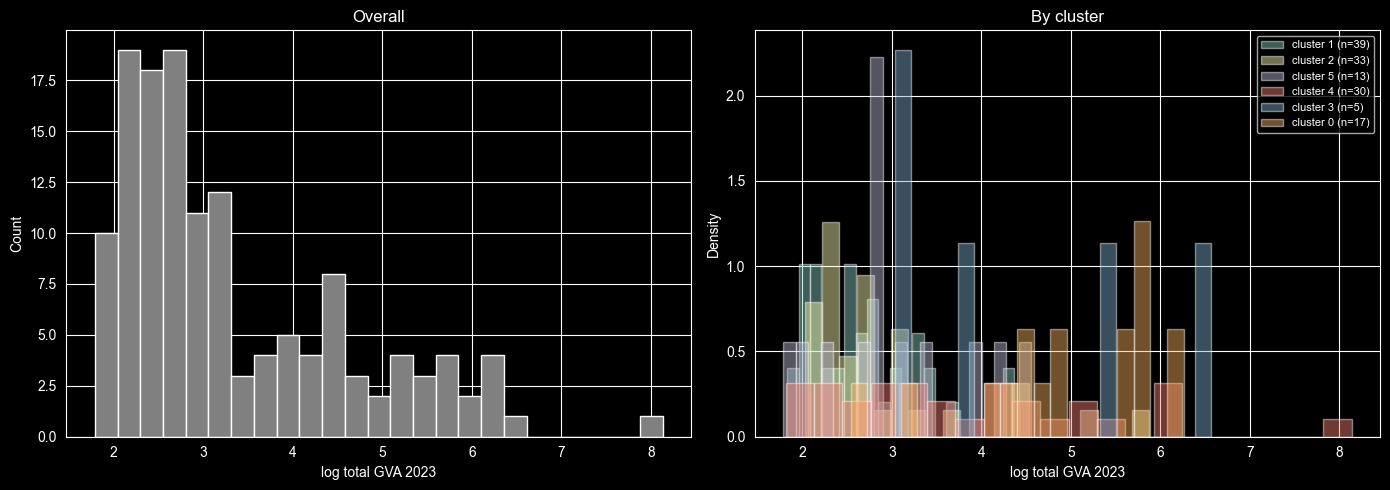

In [6]:
order = df.groupby("cluster")["log_total_GVA_2023"].mean().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["log_total_GVA_2023"], bins=25, color="grey", edgecolor="white")
axes[0].set_title("Overall")
axes[0].set_xlabel("log total GVA 2023")
axes[0].set_ylabel("Count")

for cl in order:
    vals = df.loc[df["cluster"] == cl, "log_total_GVA_2023"]
    axes[1].hist(vals, bins=20, density=True, alpha=0.45, label=f"cluster {cl} (n={len(vals)})")
axes[1].set_title("By cluster")
axes[1].set_xlabel("log total GVA 2023")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

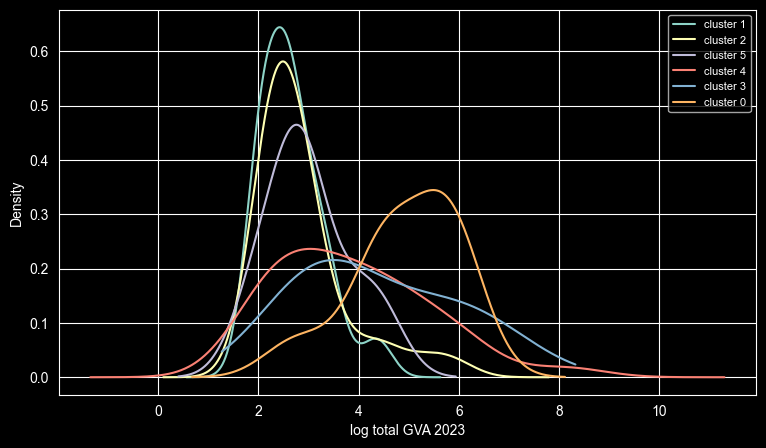

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for cl in order:
    vals = df.loc[df["cluster"] == cl, "log_total_GVA_2023"]
    if len(vals) >= 3:
        vals.plot.kde(ax=ax, label=f"cluster {cl}")
ax.set_xlabel("log total GVA 2023")
ax.legend(fontsize=8)
plt.show()

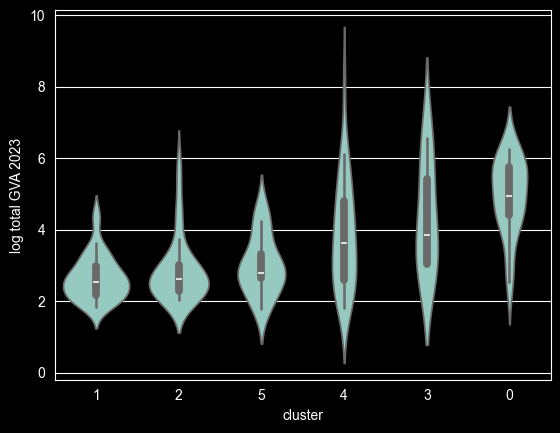

In [4]:
sns.violinplot(data=df, x="cluster", y="log_total_GVA_2023", order=order)
plt.xlabel("cluster")
plt.ylabel("log total GVA 2023")
plt.show()

In [8]:
groups = [g["log_total_GVA_2023"].values for _, g in df.groupby("cluster")]
grand = df["log_total_GVA_2023"]
ss_between = sum(len(g) * (g.mean() - grand.mean()) ** 2 for g in groups)
eta2 = ss_between / ((grand - grand.mean()) ** 2).sum()
f, p_anova = stats.f_oneway(*groups)
h, p_kw = stats.kruskal(*groups)
print(f"eta^2: {eta2:.3f}")
print(f"ANOVA: F={f:.2f}, p={p_anova:.2e}")
print(f"Kruskal-Wallis: H={h:.2f}, p={p_kw:.2e}")

eta^2: 0.368
ANOVA: F=15.23, p=8.76e-12
Kruskal-Wallis: H=43.10, p=3.53e-08
